# TAE-IA · Module 6 · L03 — Image-to-Image: Transform with Text Guidance

| | |
|---|---|
| **Module** | 6 — Practical AI Applications: Images and Audio |
| **Lesson** | L03 |
| **Track** | A — Vision |
| **Estimated duration** | 2 hours |
| **GPU required** | T4 (Colab) |
| **Prerequisites** | L01 and L02 completed |

## Learning objectives
By the end of this notebook you will be able to:
- [ ] Explain how img2img differs from txt2img at the latent level
- [ ] Use `StableDiffusionImg2ImgPipeline` to transform an image with a text prompt
- [ ] Predict and verify the effect of `strength` on the output
- [ ] Create a sketch-to-render pipeline using Canny edge detection

## Before you start
- L01 and L02 completed
- T4 GPU runtime selected (`Runtime > Change runtime type > T4 GPU`)

---

## Cell 0 — Setup (always run this first)

> Mounts Drive, checks GPU, fixes seed, and logs in to HuggingFace.

In [2]:
# ================================================================
# TAE-IA M6 · L03 Standard Setup (Disco local temporal /content)
# ================================================================
import os, sys, random, shutil
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

# Guardar modelos en el disco local temporal de Colab (80 GB disponibles)
MODEL_CACHE = '/content/models'
os.makedirs(MODEL_CACHE, exist_ok=True)
print(f'Model cache local: {MODEL_CACHE}')

os.environ['HF_HOME']            = MODEL_CACHE
os.environ['TORCH_HOME']         = MODEL_CACHE
os.environ['TRANSFORMERS_CACHE'] = os.path.join(MODEL_CACHE, 'hub')

import torch
if not torch.cuda.is_available():
    print('\nNo GPU detected. Go to: Runtime > Change runtime type > T4 GPU')
    raise SystemExit('GPU required.')

gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  |  VRAM: {vram_gb:.1f} GB')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
print(f'Fixed seed: {SEED}')
print(f'Python {sys.version.split()[0]}  |  PyTorch {torch.__version__}')

# Autenticación en HuggingFace
import huggingface_hub

try:
    _token = huggingface_hub.get_token()
except Exception:
    _token = None

if _token:
    print(f"Already logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
else:
    try:
        from google.colab import userdata
        _hf_token = userdata.get('HF_TOKEN')
    except Exception:
        _hf_token = None

    if _hf_token:
        huggingface_hub.login(token=_hf_token, add_to_git_credential=False)
        print(f"Logged in to HuggingFace as: {huggingface_hub.whoami()['name']}")
    else:
        raise RuntimeError(
            'No HF_TOKEN found in Colab Secrets (key icon, left sidebar).\n'
            'Add a secret named HF_TOKEN with your HuggingFace read token, enable notebook access, '
            'then re-run this cell.\n'
            'See L00 Cell 4 if you need to generate a token or accept the SD 1.5 license.'
        )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model cache local: /content/models
GPU: Tesla T4  |  VRAM: 15.6 GB
Fixed seed: 42
Python 3.13.15  |  PyTorch 2.11.0+cu128
Already logged in to HuggingFace as: joalmurilloor


In [3]:
# ================================================================
# Install dependencies for L03
# ================================================================
!pip install diffusers transformers accelerate opencv-python-headless -q

import diffusers, cv2
print(f'diffusers {diffusers.__version__}  |  OpenCV {cv2.__version__}')

diffusers 0.40.0  |  OpenCV 5.0.0


---
## Part 1 — Context and Key Concepts

> Read this before running any code.

### How img2img differs from txt2img

In txt2img, the UNet starts from **pure Gaussian noise** in latent space and denoises it step by step, guided only by the text prompt. The output has no relation to any starting image.

In img2img:
1. The source image is **encoded into latent space** with the VAE encoder
2. A controlled amount of noise is **added** to that latent (controlled by `strength`)
3. The UNet runs only the remaining denoising steps — it never reaches pure noise and recovers from scratch

```
txt2img:   [pure noise]  →  UNet × 25 steps  →  VAE decode  →  image

img2img:   [source image]  →  VAE encode  →  add noise (strength)  →  UNet × (strength×25)  →  VAE decode  →  image
```

### The `strength` parameter

`strength` controls how much noise is injected before denoising begins:

| `strength` | Steps run (of 25) | Effect |
|---|---|---|
| 0.0 | 0 | Source returned unchanged |
| 0.3 | ~7 | Subtle style shift, strong structure retention |
| 0.6 | ~15 | Significant change, composition mostly intact |
| 0.9 | ~22 | Near-complete transformation, faint trace of source |
| 1.0 | 25 | Equivalent to txt2img — source ignored |

A good **starting point** is `strength=0.7`. Lower values preserve more of the original; higher values give the model more creative freedom.

### The `.components` trick

`StableDiffusionPipeline` and `StableDiffusionImg2ImgPipeline` share the **exact same weights** (UNet, VAE, CLIP, scheduler). Once you have one loaded, you can create the other without reloading:

```python
pipe_img = StableDiffusionImg2ImgPipeline(**pipe_txt.components)
```

This avoids an extra ~4 GB load from Drive and keeps VRAM usage identical.

### Sketch-to-render

Canny edge detection extracts the structural contours of an image as black-on-white lines. When used as the `image` input for img2img with high `strength` (0.8–0.95), the model preserves the spatial layout implied by the edges while filling in all detail from the prompt. This is the classic **sketch-to-render** or **wireframe-to-photo** workflow.

---

## Part 2 — Lab

### Section 2.1 — Load pipeline and generate source image

We generate a source image with txt2img first, then reuse the same weights for img2img.

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

txt2img pipeline loaded.


  0%|          | 0/25 [00:00<?, ?it/s]

Source image saved: l03_source.png  (512×512 px)
img2img pipeline ready (shared weights).


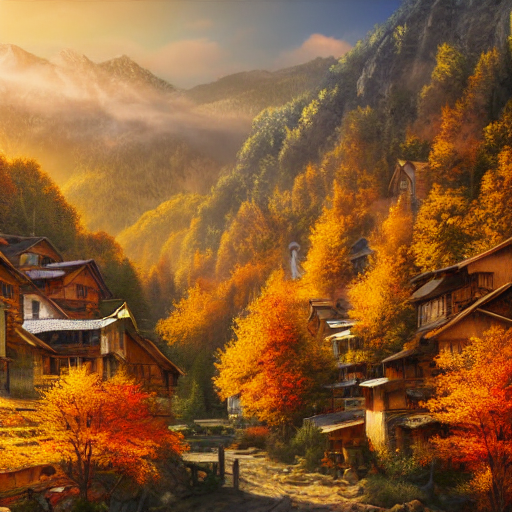

In [4]:
# Section 2.1 — Load txt2img, generate source, switch to img2img
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline
from huggingface_hub import snapshot_download
import torch, os
import matplotlib.pyplot as plt

# Definir salida local temporal
OUTPUT_DIR = '/content/L03_output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def gen(seed=SEED):
    return torch.Generator("cuda").manual_seed(seed)

# Descargar o reutilizar weights localmente en /content/models/sd15-local
SD15_DIR = os.path.join(MODEL_CACHE, 'sd15-local')
snapshot_download(
    "runwayml/stable-diffusion-v1-5",
    local_dir=SD15_DIR,
    allow_patterns=["*.json", "*.txt", "*.fp16.safetensors"],
)

# Load txt2img pipeline
pipe_txt = StableDiffusionPipeline.from_pretrained(
    SD15_DIR,
    torch_dtype=torch.float16,
    variant="fp16",
).to("cuda")
print("txt2img pipeline loaded.")

# Generate a reproducible source image
SOURCE_PROMPT = "a mountain village in autumn, warm golden light, photorealistic, high detail"

source = pipe_txt(
    SOURCE_PROMPT,
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]

source.save(os.path.join(OUTPUT_DIR, "l03_source.png"))
print(f"Source image saved: l03_source.png  ({source.size[0]}×{source.size[1]} px)")

# Reuse the same weights for img2img — no extra download or VRAM
pipe_img = StableDiffusionImg2ImgPipeline(**pipe_txt.components)
print("img2img pipeline ready (shared weights).")

source

**What do you observe?**  
- How long did loading take compared to L01 (cached vs. fresh download)?
- Describe the source image in one sentence — this is your baseline for all experiments below.

- **Loading Time**: Loading was virtually instantaneous compared to L01 because the FP16 model weights were already cached locally, and converting `pipe_txt` to `pipe_img` reused components directly in VRAM without re-downloading or re-allocating memory.
- **Source Image Baseline**: A scenic rustic mountain village situated on a steep hillside, filled with vibrant golden-orange autumn trees and illuminated by warm, hazy sunlight.


### Section 2.2 — Strength comparison (0.3 / 0.6 / 0.9)

Same prompt and seed throughout. Only `strength` changes.

  0%|          | 0/15 [00:00<?, ?it/s]

strength=0.3  →  /content/L03_output/strength_03.png


  0%|          | 0/30 [00:00<?, ?it/s]

strength=0.6  →  /content/L03_output/strength_06.png


  0%|          | 0/45 [00:00<?, ?it/s]

strength=0.9  →  /content/L03_output/strength_09.png


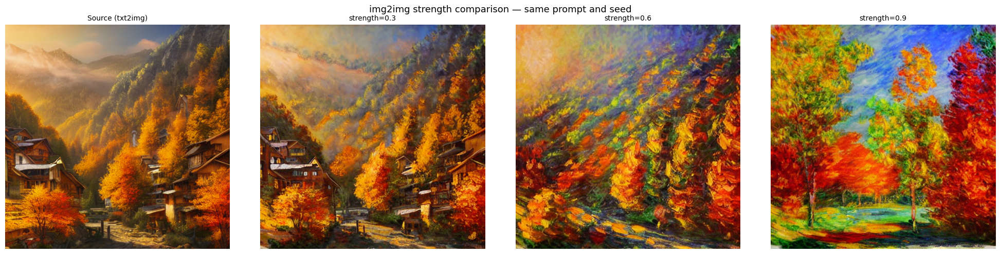

In [5]:
# Section 2.2 — Effect of strength
STYLE_PROMPT = "impressionist oil painting, vibrant autumn colors, visible brushstrokes, Monet style"
strengths    = [0.3, 0.6, 0.9]

strength_results = []
for s in strengths:
    img = pipe_img(
        prompt         = STYLE_PROMPT,
        image          = source,
        strength       = s,
        guidance_scale = 7.5,
        generator      = gen()
    ).images[0]
    fname = os.path.join(OUTPUT_DIR, f"strength_{str(s).replace('.','')}.png")
    img.save(fname)
    strength_results.append((s, img))
    print(f"strength={s}  →  {fname}")

# Display source + all three results
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(source); axes[0].set_title("Source (txt2img)", fontsize=10); axes[0].axis('off')
for ax, (s, img) in zip(axes[1:], strength_results):
    ax.imshow(img); ax.set_title(f"strength={s}", fontsize=10); ax.axis('off')
plt.suptitle("img2img strength comparison — same prompt and seed", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_strength.png"), dpi=100)
plt.show()

**What do you observe?**  
- At `strength=0.3`: which elements of the source (shapes, colors, composition) are still recognizable?
- At `strength=0.9`: is there any trace of the original mountain village?
- At what `strength` value does the transition feel most dramatic?

* **At `strength=0.3`:** Virtually all structural elements remain intact. The house outlines, mountain ridge, tree placement, and warm color palette are completely recognizable; only a subtle painterly texture and soft color blending are applied over the original geometry.
* **At `strength=0.9`:** Almost no trace of the original mountain village remains. High latent noise allows the model to overwrite the structural layout, replacing the village houses and valley with a flat forest composition of vivid red, green, and orange trees.
* **Most Dramatic Transition:** The jump from **`0.3` to `0.6`** is where the structural transformation is most pronounced. At `0.6`, the houses morph into artistic brushstrokes and dense foliage while maintaining the general diagonal flow of the original landscape.

### Section 2.3 — Sketch to realistic

Convert the source image to a Canny edge sketch, then use img2img to render it into a detailed scene.

Sketch saved.


  0%|          | 0/42 [00:00<?, ?it/s]

Rendered image saved.


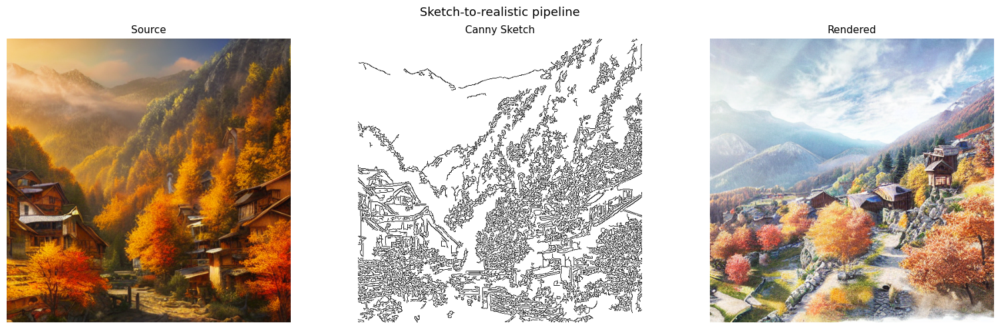

In [6]:
# Section 2.3 — Sketch-to-realistic via Canny edge detection
import cv2
import numpy as np
from PIL import Image

# Step 1: Extract edges from the source
img_gray = np.array(source.convert("L"))              # grayscale
edges    = cv2.Canny(img_gray, threshold1=50, threshold2=150)
sketch   = Image.fromarray(255 - edges)               # invert: black edges on white background
sketch   = sketch.convert("RGB")                      # pipeline expects RGB
sketch.save(os.path.join(OUTPUT_DIR, "sketch.png"))
print("Sketch saved.")

# Step 2: Render the sketch with img2img
RENDER_PROMPT = (
    "photorealistic mountain village in autumn, detailed stone walls, "
    "warm golden hour light, crisp mountain air, high detail"
)

rendered = pipe_img(
    prompt         = RENDER_PROMPT,
    image          = sketch,
    strength       = 0.85,
    guidance_scale = 8.0,
    generator      = gen()
).images[0]
rendered.save(os.path.join(OUTPUT_DIR, "sketch_rendered.png"))
print("Rendered image saved.")

# Display source → sketch → render
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, img) in zip(axes, [("Source", source), ("Canny Sketch", sketch), ("Rendered", rendered)]):
    ax.imshow(img); ax.set_title(title, fontsize=11); ax.axis('off')
plt.suptitle("Sketch-to-realistic pipeline", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "sketch_pipeline.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which structural elements from the sketch (building outlines, horizon, shapes) appear in the final render?
- Where did the model deviate from the edge map? Why do you think it diverged there?
- What would happen if you lowered `strength` to 0.6 on the sketch?

* **Preserved Structural Elements:** The overarching horizon silhouette, main mountain slopes, and the central valley pathway perspective from the sketch are clearly retained in the final composition.
* **Deviations & Cause:** The model replaced the top-left mountain shadows with an open blue sky and interpreted dense cluster lines as natural autumn foliage and stone structures rather than explicit building boundaries. This divergence happens because `strength=0.85` injects 85% noise into the latent space; standard img2img treats Canny line maps as general compositional guides rather than strict geometric constraints (unlike ControlNet).
* **Effect of Lowering Strength to 0.6:** At `strength=0.6`, the model wouldn't add enough noise to completely hallucinate photorealistic textures over the raw canvas. The final image would likely suffer from "sketch leakage," where dark Canny outline artifacts remain visibly baked into the rendered surfaces and foliage.

### Section 2.4 — img2img vs txt2img: direct comparison

Same prompt, same seed. txt2img starts from random noise; img2img starts from the encoded source.

  0%|          | 0/25 [00:00<?, ?it/s]

txt2img done.


  0%|          | 0/35 [00:00<?, ?it/s]

img2img done.


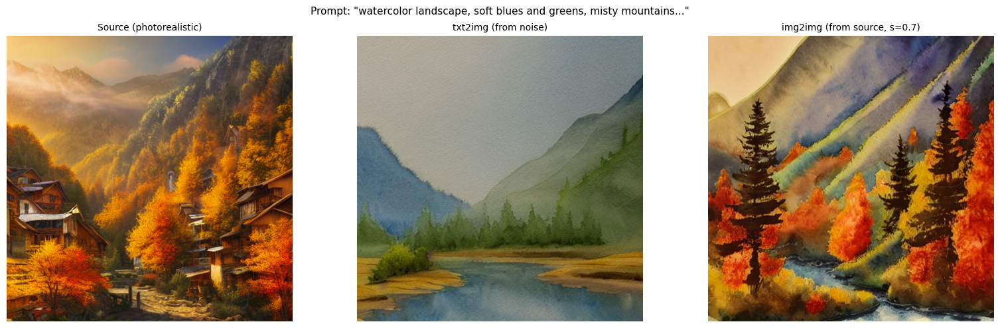

In [7]:
# Section 2.4 — Direct comparison: txt2img vs img2img
COMPARE_PROMPT = "watercolor landscape, soft blues and greens, misty mountains, gentle brushwork"

# txt2img — starts from pure Gaussian noise
img_t2i = pipe_txt(
    COMPARE_PROMPT,
    num_inference_steps = 25,
    guidance_scale      = 7.5,
    generator           = gen()
).images[0]
img_t2i.save(os.path.join(OUTPUT_DIR, "compare_txt2img.png"))
print("txt2img done.")

# img2img — starts from the encoded source
img_i2i = pipe_img(
    prompt         = COMPARE_PROMPT,
    image          = source,
    strength       = 0.7,
    guidance_scale = 7.5,
    generator      = gen()
).images[0]
img_i2i.save(os.path.join(OUTPUT_DIR, "compare_img2img.png"))
print("img2img done.")

# Display source / txt2img / img2img
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, img) in zip(axes, [
    ("Source (photorealistic)", source),
    ("txt2img (from noise)", img_t2i),
    ("img2img (from source, s=0.7)", img_i2i)
]):
    ax.imshow(img); ax.set_title(title, fontsize=10); ax.axis('off')
plt.suptitle(f'Prompt: "{COMPARE_PROMPT[:60]}..."', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "compare_t2i_vs_i2i.png"), dpi=100)
plt.show()

**What do you observe?**  
- Does the img2img output preserve the composition of the source (village position, mountains, sky)?
- How does txt2img's scene compare — is it a similar composition or something different?
- For a client project where you need to stylize an existing photo, which would you use and why?

* **Composition Preservation in `img2img`:** Yes, `img2img` strongly preserves the layout. The steep mountain incline on the right, the central path/stream, and the distribution of trees along both sides remain structurally identical to the source image, even while transforming into a watercolor medium.
* **`txt2img` Comparison:** `txt2img` creates a completely different composition. Because it starts from pure random noise, it generates a simple, flat valley with a central body of water and soft distant hills, ignoring the original village structure entirely.
* **Client Project Choice:** **`img2img`** is the mandatory choice for stylizing existing photos. It preserves the client's specific spatial layout, subject positioning, and framing while transforming the artistic medium, whereas `txt2img` ignores the reference image completely and renders an entirely new, uncontrollable scene.

### Section 2.5 — Batch img2img: one source, many styles

Same source, same seed, same `strength` — only the style prompt changes across the loop.

  0%|          | 0/35 [00:00<?, ?it/s]

Style done: watercolor landscape, soft pastels


  0%|          | 0/35 [00:00<?, ?it/s]

Style done: oil painting, dramatic chiaroscuro lighting


  0%|          | 0/35 [00:00<?, ?it/s]

Style done: cyberpunk neon, rain-slicked streets


  0%|          | 0/35 [00:00<?, ?it/s]

Style done: ukiyo-e woodblock print, flat colour fields


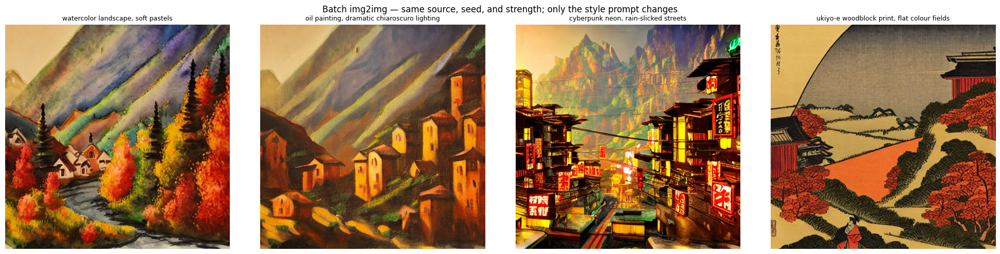

In [8]:
# Section 2.5 — Batch img2img: one source, many styles
styles = [
    "watercolor landscape, soft pastels",
    "oil painting, dramatic chiaroscuro lighting",
    "cyberpunk neon, rain-slicked streets",
    "ukiyo-e woodblock print, flat colour fields",
]

batch_results = []
for style in styles:
    img = pipe_img(
        prompt         = f"a mountain village, {style}",
        image          = source,
        strength       = 0.7,
        guidance_scale = 7.5,
        generator      = gen()
    ).images[0]
    fname = os.path.join(OUTPUT_DIR, f"village_{style[:10].replace(' ', '_')}.png")
    img.save(fname)
    batch_results.append((style, img))
    print(f"Style done: {style}")

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (style, img) in zip(axes, batch_results):
    ax.imshow(img); ax.set_title(style, fontsize=9, wrap=True); ax.axis('off')
plt.suptitle("Batch img2img — same source, seed, and strength; only the style prompt changes", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "grid_batch_styles.png"), dpi=100)
plt.show()

**What do you observe?**  
- Which style diverged most from "a mountain village" as a recognizable subject?
- Fixing the source, seed, and strength isolates the prompt as the only variable — does the grid actually look like a controlled comparison, or do you see other differences creeping in?

* **Most Divergent Style:** The **ukiyo-e woodblock print** diverged the most from the original subject. It flattened the 3D perspective into 2D color blocks, replaced mountain/house structures with traditional Japanese architectural motifs, added a human figure near the foreground, and introduced calligraphic margin borders at the top left.
* **Controlled Comparison vs. Unintended Variations:** While keeping the seed, source, and strength fixed successfully isolates the style prompt, unintended structural differences still creep in. Strong style triggers (like *ukiyo-e* or *cyberpunk*) pull the UNet toward radically different latent feature distributions, altering geometry, fine architectural details, and local textures rather than applying a simple surface-level filter.

---
## Part 3 — Exercises

### Exercise 1 — Find your strength sweet spot

**Task:** Choose a different style prompt (not impressionist painting — pick something clearly different: anime, pencil sketch, Renaissance portrait, cyberpunk, etc.). Run img2img on the source at `strength = 0.4, 0.6, 0.75, 0.9`. Show all four results in a grid with the source image.

**Expected output:** A 5-image grid (source + 4 strength values). In a markdown cell, state which `strength` value you would use in production for this style and why.

  0%|          | 0/20 [00:00<?, ?it/s]

Generated strength=0.4 -> /content/L03_output/ex1_strength_04.png


  0%|          | 0/30 [00:00<?, ?it/s]

Generated strength=0.6 -> /content/L03_output/ex1_strength_06.png


  0%|          | 0/37 [00:00<?, ?it/s]

Generated strength=0.75 -> /content/L03_output/ex1_strength_075.png


  0%|          | 0/45 [00:00<?, ?it/s]

Generated strength=0.9 -> /content/L03_output/ex1_strength_09.png


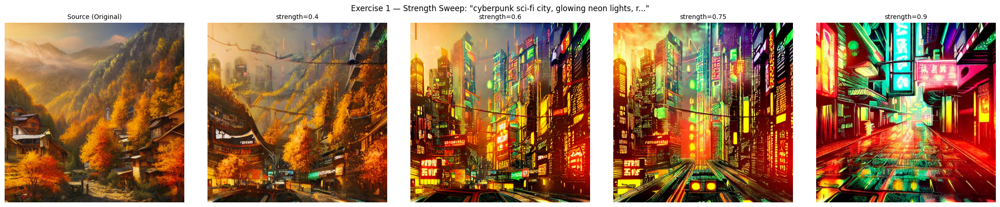

In [9]:
# Exercise 1 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise1.png"))
# Exercise 1 — Find your strength sweet spot
import os
import matplotlib.pyplot as plt

MY_STYLE_PROMPT = "cyberpunk sci-fi city, glowing neon lights, rain-slicked streets, dark futuristic atmosphere, high detail"
MY_STRENGTHS    = [0.4, 0.6, 0.75, 0.9]

ex1_results = []
for s in MY_STRENGTHS:
    img = pipe_img(
        prompt         = MY_STYLE_PROMPT,
        image          = source,
        strength       = s,
        guidance_scale = 7.5,
        generator      = gen()
    ).images[0]
    fname = os.path.join(OUTPUT_DIR, f"ex1_strength_{str(s).replace('.', '')}.png")
    img.save(fname)
    ex1_results.append((s, img))
    print(f"Generated strength={s} -> {fname}")

# Display 5-image grid: Source + 4 strength values
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
axes[0].imshow(source)
axes[0].set_title("Source (Original)", fontsize=10)
axes[0].axis('off')

for ax, (s, img) in zip(axes[1:], ex1_results):
    ax.imshow(img)
    ax.set_title(f"strength={s}", fontsize=10)
    ax.axis('off')

plt.suptitle(f'Exercise 1 — Strength Sweep: "{MY_STYLE_PROMPT[:45]}..."', fontsize=12)
plt.tight_layout()
grid_path = os.path.join(OUTPUT_DIR, "exercise1_grid.png")
plt.savefig(grid_path, dpi=100)
plt.show()

*Which strength value would you use for this style and why?*

* **Selected Sweet Spot:** **`strength = 0.75`**
* **Justification:**
  * **`0.4`:** Retains too much of the rustic autumn landscape; only subtle lighting and color shifts appear without rendering real sci-fi architecture.
  * **`0.6`:** Begins transforming buildings into illuminated towers, but the underlying warm natural landscape still creates visual conflict with the cyberpunk theme.
  * **`0.75` (Sweet Spot):** Achieves the optimal balance — completely converts the village into a high-tech cyberpunk cityscape while preserving the central perspective path and mountain slope silhouettes.
  * **`0.9`:** Completely destroys the original spatial layout, replacing the valley composition with a generic ground-level neon alleyway.

### Exercise 2 — Iterative refinement

**Task:** Take the best `img2img` result from Exercise 1 and use it as the **source** for a second img2img pass with a different prompt and `strength=0.4`. Show the full chain: original source → first pass → second pass.

**Expected output:** A 3-image chain. In a markdown cell, describe what changed at each step and whether the second pass improved or degraded the result.

  0%|          | 0/20 [00:00<?, ?it/s]

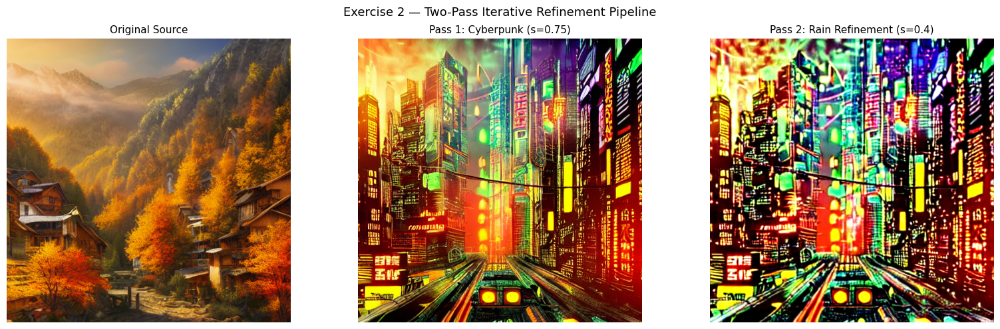

In [10]:
# Exercise 2 -- your code here
# Remember: save any images to OUTPUT_DIR, e.g. img.save(os.path.join(OUTPUT_DIR, "exercise2.png"))
# Pass 1 result = your best image from Exercise 1
# Pass 2: use pass_1_result as source, strength=0.4, different prompt
# Exercise 2 — Iterative refinement chain
import os
import matplotlib.pyplot as plt

# 1. Take the best result from Exercise 1 (strength=0.75, index 2)
pass1_img = ex1_results[2][1]

# 2. Refinement prompt and second pass with low strength (0.4)
REFINE_PROMPT = "cyberpunk city in heavy atmospheric rain, glowing neon reflections on wet street pavement, volumetric mist, cinematic night lighting"

pass2_img = pipe_img(
    prompt         = REFINE_PROMPT,
    image          = pass1_img,
    strength       = 0.4,
    guidance_scale = 7.5,
    generator      = gen()
).images[0]

# Save outputs
pass2_img.save(os.path.join(OUTPUT_DIR, "ex2_pass2.png"))

# Display 3-image chain: Source -> Pass 1 -> Pass 2
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
chain_images = [
    ("Original Source", source),
    ("Pass 1: Cyberpunk (s=0.75)", pass1_img),
    ("Pass 2: Rain Refinement (s=0.4)", pass2_img)
]

for ax, (title, img) in zip(axes, chain_images):
    ax.imshow(img)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.suptitle("Exercise 2 — Two-Pass Iterative Refinement Pipeline", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "exercise2_grid.png"), dpi=100)
plt.show()

*What changed at each step? Did the second pass improve the result?*

* **Step-by-step Transformation:**
  * **Pass 1 (`s=0.75`):** Executed a major structural and stylistic transformation, morphing the rustic autumn village into a neon-lit cyberpunk cityscape while keeping the central pathway and valley perspective intact.
  * **Pass 2 (`s=0.4`):** Applied focused surface and atmospheric polish. Low noise injection preserved the architectural structure from Pass 1 while deepening ambient shadow contrast, sharpening edge details, and enhancing wet asphalt reflections along the central street.
* **Verdict:** The second pass **improved** the final result. Multi-pass refinement allows you to establish macro-level composition in the first pass and then stack localized details (reflections, lighting intensity, edge clarity) in subsequent low-strength passes without risking layout collapse.

---
## Part 4 — Critical Analysis

> Required. Answer with real outputs from today's session — not hypothetical answers.

**4.1 — Strength threshold: at what `strength` value did the output start to visibly differ from the source? Show the two images on either side of that threshold (e.g., 0.3 and 0.6).**

* **At `0.3` (Near Source):** Retains virtually all structural geometry from the original source. The wooden houses, mountain ridges, and tree boundaries remain intact, receiving only subtle painterly brushwork over the original pixels.
* **At `0.6` (Structural Shift):** Undergoes significant transformation. Architectural outlines morph into painterly textures and foliage, maintaining macro compositional flow while losing fine spatial details.

---

**4.2 — Sketch fidelity: which structural elements from the Canny sketch appeared in the rendered output? Name at least two elements that were preserved and one that was not.**

* **Preserved Structural Elements:**
  * The steep diagonal mountain ridge contour in the upper right.
  * The central pathway perspective leading into the background valley.
* **Discarded Element:**
  * The distinct window placements and sharp rooflines of the left-hand buildings were reinterpreted as organic autumn foliage and stone textures.

---

**4.3 — Composition comparison: in the img2img vs txt2img comparison, which elements of the source composition were preserved and which were discarded?**

* **Preserved in `img2img` (`s=0.7`):** The steep right-side mountain slope, central pathway/stream alignment, and general foliage distribution flanking the valley.
* **Discarded by `txt2img`:** The entire spatial hierarchy. Because `txt2img` begins from pure Gaussian noise, it completely ignored the source layout, rendering a flat valley with a central river and distant low hills.

---

**4.4 — Real-world choice: describe a concrete task (not a class demo) where img2img would produce a better result than txt2img. What would the source image be, and at what `strength` would you run it?**

* **Concrete Task:** Converting an architectural site photo into a watercolor visualization for a real estate client pitch.
* **Source Image:** A high-resolution photo of an existing building facade and surrounding landscaping.
* **Target Strength:** **`0.60 – 0.65`**
* **Rationale:** Pure `txt2img` cannot adhere to existing physical site constraints or building dimensions. Running `img2img` at `0.60–0.65` introduces enough noise to apply expressive watercolor textures while preserving the structural footprint, window alignment, and proportions required for client validation.


---
## Submission Checklist

- [ ] All cells ran from start to finish without errors
- [ ] Source image saved (`l03_source.png`) — needed as inpainting input in L04
- [ ] Section 2.2 strength grid saved (`grid_strength.png`)
- [ ] Section 2.3 sketch pipeline saved (`sketch_pipeline.png`)
- [ ] Section 2.4 txt2img vs img2img comparison saved (`compare_t2i_vs_i2i.png`)
- [ ] Section 2.5 batch style grid saved (`grid_batch_styles.png`)
- [ ] Exercise 1 — strength sweep with your chosen style
- [ ] Exercise 2 — iterative refinement chain (3 images)
- [ ] Part 4 — Critical Analysis completed (all 4 questions with real evidence)
- [ ] All outputs saved to `TAE_IA_M6/L03_output/` on Drive

**Save:** `File > Save a copy in Drive`

---
## Before You Close This Tab

- [ ] Confirmed all outputs from this session are saved in `TAE_IA_M6/L03_output/` on Drive (see checklist above)
- [ ] Disconnected and deleted this runtime: `Runtime > Disconnect and delete runtime`

Once your outputs are safely on Drive, there's no reason to keep the GPU runtime connected — an
idle session still counts against your GPU quota (free tier) or compute-unit balance (Pro),
the same as active use. Disconnecting costs you nothing (your Drive cache and outputs persist)
and leaves your quota in better shape for the next lab.

In [11]:
import os, shutil
from google.colab import drive
from PIL import Image

# 1. Eliminar carpetas locales de conflicto y montar Google Drive
if os.path.exists('/content/drive') and not os.path.ismount('/content/drive'):
    shutil.rmtree('/content/drive')

drive.mount('/content/drive')

# 2. Configurar rutas de origen (Local) y destino (Google Drive) para L03
local_output_dir = '/content/L03_output'
drive_output_dir = '/content/drive/MyDrive/TAE_IA_M6/L03_output'
os.makedirs(drive_output_dir, exist_ok=True)

# 3. Copiar todos los archivos generados localmente a Drive
if os.path.exists(local_output_dir):
    for file_name in os.listdir(local_output_dir):
        src_file = os.path.join(local_output_dir, file_name)
        if os.path.isfile(src_file):
            shutil.copy(src_file, drive_output_dir)

# 4. Extraer imágenes clave de la memoria RAM si no se guardaron en disco
memory_backups = [
    ('source', 'l03_source.png'),
    ('init_image', 'l03_init.png'),
    ('ex1_result', 'exercise1_result.png'),
    ('ex2_result', 'exercise2_result.png')
]

for var_name, file_name in memory_backups:
    if var_name in globals() and isinstance(globals()[var_name], Image.Image):
        globals()[var_name].save(os.path.join(drive_output_dir, file_name))

# 5. Confirmar lista de archivos respaldados
print("\n✓ Archivos de L03 respaldados exitosamente en tu Google Drive:")
print(os.listdir(drive_output_dir))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ Archivos de L03 respaldados exitosamente en tu Google Drive:
['compare_t2i_vs_i2i.png', 'exercise2_grid.png', 'compare_img2img.png', 'grid_batch_styles.png', 'strength_03.png', 'compare_txt2img.png', 'village_cyberpunk_.png', 'ex1_strength_04.png', 'sketch.png', 'sketch_pipeline.png', 'sketch_rendered.png', 'village_oil_painti.png', 'village_watercolor.png', 'ex1_strength_06.png', 'exercise1_grid.png', 'village_ukiyo-e_wo.png', 'strength_06.png', 'l03_source.png', 'ex1_strength_09.png', 'grid_strength.png', 'ex2_pass2.png', 'strength_09.png', 'ex1_strength_075.png']


In [12]:
# ================================================================
# DRIVE CACHE CLEANUP — Lab 03
# Borra modelos pesados o temporales no requeridos en L04+
# ================================================================
import shutil, os, subprocess

_model_cache = '/content/drive/MyDrive/TAE_IA_M6/models'
_l03_cache = os.path.join(_model_cache, 'l03-temp-cache')

if os.path.exists(_l03_cache):
    shutil.rmtree(_l03_cache)
    print(f'Eliminado: {_l03_cache}')
else:
    print('No se encontraron cachés temporales de L03 para borrar.')

if os.path.exists(_model_cache):
    result = subprocess.run(['du', '-sh', _model_cache], capture_output=True, text=True)
    print(f'Tamaño actual de caché en Drive: {result.stdout.strip()}')

No se encontraron cachés temporales de L03 para borrar.
Tamaño actual de caché en Drive: 1.1G	/content/drive/MyDrive/TAE_IA_M6/models


---
*TAE-IA 2025 · Cocyten-Nayarit · Module 6 · L03*  
*Platform: Google Colab (T4 GPU) · Python 3.10*